In [1]:
import pandas as pd
import sklearn as sk



df = pd.read_csv("../data/Premier_League/PremierLeague_Match_Data_Ready_For_ML.csv", parse_dates=['Date'])


df = df.drop(columns=[col for col in df.columns if 'Away_H2H' in col])
df = df.drop(columns=['Div','Date','HomeTeam', 'AwayTeam', 'Season', 'Referee'])

print(df.info())
print(df.head())
print(df.describe())
print(f"Number of columns after feature selection: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 9719 entries, 0 to 9718
Data columns (total 72 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Target                             9719 non-null   int64  
 1   Home_DaysOfRest                    9719 non-null   float64
 2   Away_DaysOfRest                    9719 non-null   float64
 3   Home_Last5_HomePts                 9719 non-null   float64
 4   Home_Last5_GF                      9719 non-null   float64
 5   Home_Last5_HomeShots               9719 non-null   float64
 6   Home_Last5_HomeShotsOT             9719 non-null   float64
 7   Home_Last5_Corners                 9719 non-null   float64
 8   Home_Last5_HomeFouls               9719 non-null   float64
 9   Home_Last5_HomeYellows             9719 non-null   float64
 10  Home_Last5_HomeReds                9719 non-null   float64
 11  Home_Last5_GA                      9719 non-null   float64
 12  Hom

In [2]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
X= df.drop('Target',axis=1)
y = df['Target']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f"Number of matches for training: {X_train.shape[0]}")
print(f"Number of matches for testing: {X_test.shape[0]}\n")

Number of matches for training: 7775
Number of matches for testing: 1944



In [3]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [4]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print()
print(f"Overall model accuracy: {accuracy * 100:.2f}%\n")

print(classification_report(y_train, model.predict(X_train)))
print(classification_report(y_test, y_pred))


Overall model accuracy: 52.57%

              precision    recall  f1-score   support

           0       0.52      0.55      0.53      2290
           1       0.84      0.02      0.05      1936
           2       0.56      0.85      0.68      3549

    accuracy                           0.55      7775
   macro avg       0.64      0.47      0.42      7775
weighted avg       0.62      0.55      0.48      7775

              precision    recall  f1-score   support

           0       0.49      0.51      0.50       588
           1       0.17      0.00      0.00       466
           2       0.55      0.81      0.65       890

    accuracy                           0.53      1944
   macro avg       0.40      0.44      0.38      1944
weighted avg       0.44      0.53      0.45      1944



# Cross-Validation
To get a more robust estimate of the model's performance, I am using Time Series Cross-Validation. This is crucial for time-dependent data like match results, as it ensures that the model is always trained on past data and validated on future data, preventing data leakage from the future into the training set. I'm using 5 splits to evaluate the model's accuracy.

In [5]:
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X, y, cv=tscv, scoring='accuracy')
print(f"Cross validation scores = \n{scores.round(3)}")
print(f"Cross validation mean accuracy = {scores.mean() * 100:.2f}% +- {scores.std() *100 :.2f}%")

Cross validation scores = 
[0.538 0.523 0.54  0.536 0.539]
Cross validation mean accuracy = 53.53% +- 0.62%


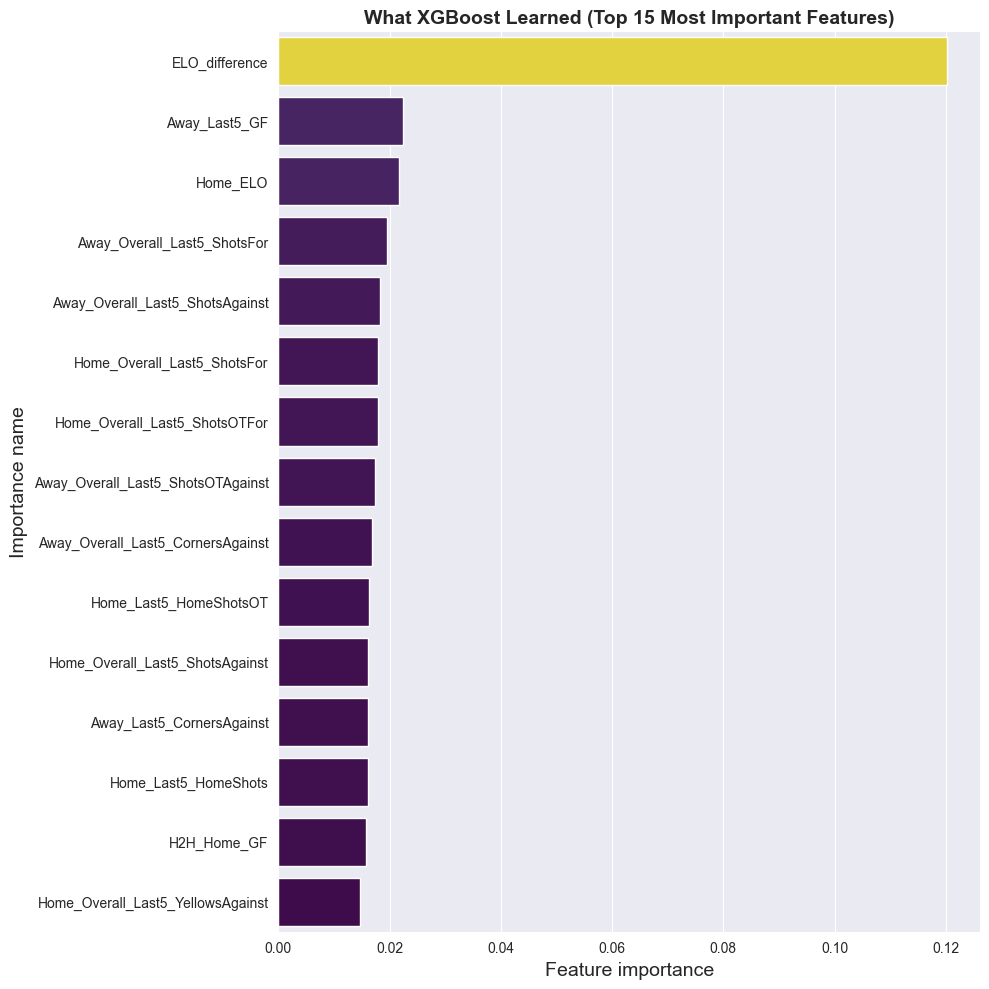

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize = (10,10))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', hue='Importance', palette='viridis', legend=False)
plt.title('What XGBoost Learned (Top 15 Most Important Features)', fontsize=14,fontweight='bold')
plt.xlabel('Feature importance', fontsize=14)
plt.ylabel('Importance name', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/xgb_model.pkl")
print("Model saved")

Model saved
